# C — Acoustic Model Dependency

Reads artifacts from Group C. **Does not recompute GOP.**

| File | Experiment |
| --- | --- |
| `outputs/C/c_predictions.csv` | C1–C3 GOP per phone |
| `outputs/C/c_results.json` | PCC / SCC / MAE / MSE |
| `outputs/A/a2_results.json` | Group A baseline (C1 must match) |

```text
python scripts/run_experiment.py --config configs/c_acoustic_model.yaml --models C1
python scripts/extract_ssl_gop.py --config configs/c_acoustic_model.yaml --model wav2vec2
python scripts/extract_ssl_gop.py --config configs/c_acoustic_model.yaml --model hubert
python scripts/run_experiment.py --config configs/c_acoustic_model.yaml
```

Protocol lock: same Speechocean762 split, Kaldi alignment, 39-phone CMU set, standard GOP, and direct scoring as Group A. Only the acoustic model changes.

C2/C3 are phoneme-CTC posteriors, **not** HuBERT/Wav2Vec2 embeddings. The three AMs are not a matched-architecture bake-off (Kaldi M13 vs XLSR-CTC vs HuBERT-CTC).


In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "C" / "c_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "C" / "c_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "C" / "c_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "C"
pred = pd.read_csv(OUT / "c_predictions.csv")
results = json.loads((OUT / "c_results.json").read_text(encoding="utf-8"))
protocol = results["protocol"]
cmp = results["comparison"]["test"]
paired = results["comparison"].get("test_paired") or {}
test = pred[pred["split"] == "test"].copy()
ids = [m for m in results.get("experiments", ["C1", "C2", "C3"]) if m in cmp]
print("ROOT", ROOT)
print(
    "models", ids,
    "n_train", protocol["n_train"],
    "n_test", protocol["n_test"],
    "n_test_c1", protocol.get("n_test_c1"),
    "n_test_paired", protocol.get("n_test_paired"),
    "C1≡A2", protocol.get("c1_matches_a2"),
)
table = pd.DataFrame({m: cmp[m] for m in ids}).T
print(table[["pcc", "scc", "mae", "mse", "n"]].round(4))
if paired:
    print("paired")
    print(pd.DataFrame(paired).T[["pcc", "scc", "mae", "mse", "n"]].round(4))

a2_path = ROOT / "outputs" / "A" / "a2_results.json"
if a2_path.is_file() and "C1" in cmp:
    a2 = json.loads(a2_path.read_text(encoding="utf-8"))["A2"]
    print("A2 test PCC", round(a2["pcc"], 4), "C1 PCC", round(cmp["C1"]["pcc"], 4))


ROOT d:\FSB_MSE\FINAL\GOP-Empirical-Study
models ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11'] n_train 47076 n_test 47369 n_test_c1 47369 n_test_paired 47308 C1≡A2 True
        pcc     scc     mae     mse        n
C1   0.3231  0.3128  0.1994  0.1203  47369.0
C2  -0.0377 -0.0066  0.2171  0.1337  47308.0
C3  -0.0602 -0.0290  0.2166  0.1334  47308.0
C4   0.0552  0.0738  0.2163  0.1335  47308.0
C5   0.3461  0.3395  0.1927  0.1202  47369.0
C6   0.0735  0.0937  0.2156  0.1332  47308.0
C7   0.3778  0.3526  0.1888  0.1170  47369.0
C8   0.4632  0.3548  0.1729  0.1078  47369.0
C9   0.4299  0.3339  0.1789  0.1122  47369.0
C10  0.4979  0.3661  0.1704  0.1030  47369.0
C11  0.4629  0.3463  0.1739  0.1080  47369.0
paired
        pcc     scc     mae     mse        n
C1   0.3204  0.3109  0.1980  0.1189  47308.0
C2  -0.0377 -0.0066  0.2171  0.1337  47308.0
C3  -0.0602 -0.0290  0.2166  0.1334  47308.0
C4   0.0552  0.0738  0.2163  0.1335  47308.0
C5   0.3437  0.3378  0.1914  0.1188 

## Test PCC / SCC by acoustic model

Δ is vs C1 on the same metric. When C2/C3 exist, prefer `test_paired` so dropped SSL phones do not inflate the gap.


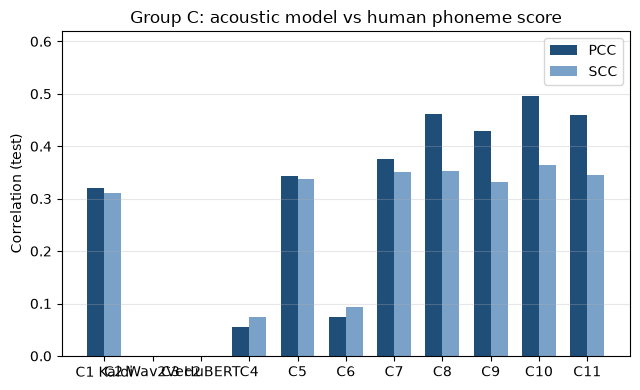

      d_pcc   d_scc   d_mae
C1   0.0000  0.0000  0.0000
C2  -0.3581 -0.3175  0.0191
C3  -0.3805 -0.3400  0.0186
C4  -0.2652 -0.2372  0.0183
C5   0.0233  0.0269 -0.0066
C6  -0.2468 -0.2173  0.0176
C7   0.0549  0.0400 -0.0105
C8   0.1408  0.0422 -0.0263
C9   0.1079  0.0213 -0.0204
C10  0.1750  0.0535 -0.0287
C11  0.1399  0.0335 -0.0251


In [4]:
use = paired if paired else cmp
ids_plot = [m for m in ids if m in use]
labels = {
    "C1": "C1 Kaldi",
    "C2": "C2 Wav2Vec2",
    "C3": "C3 HuBERT",
}
pcc = [use[i]["pcc"] for i in ids_plot]
scc = [use[i]["scc"] for i in ids_plot]
x = range(len(ids_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([i - width / 2 for i in x], pcc, width, label="PCC", color="#1f4e79")
ax.bar([i + width / 2 for i in x], scc, width, label="SCC", color="#7aa2c9")
ax.set_xticks(list(x))
ax.set_xticklabels([labels.get(i, i) for i in ids_plot])
ax.set_ylabel("Correlation (test)")
ax.set_title("Group C: acoustic model vs human phoneme score")
ymax = max(pcc + scc) if pcc or scc else 1.0
ax.set_ylim(0, ymax * 1.25 if ymax > 0 else 1)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "c_comparison_pcc.png", dpi=140)
plt.show()

if "C1" in use:
    delta = pd.DataFrame(
        {
            m: {
                "d_pcc": use[m]["pcc"] - use["C1"]["pcc"],
                "d_scc": use[m]["scc"] - use["C1"]["scc"],
                "d_mae": use[m]["mae"] - use["C1"]["mae"],
            }
            for m in ids_plot
        }
    ).T
    print(delta.round(4))


## Scatter: C1 Kaldi GOP vs human (test)


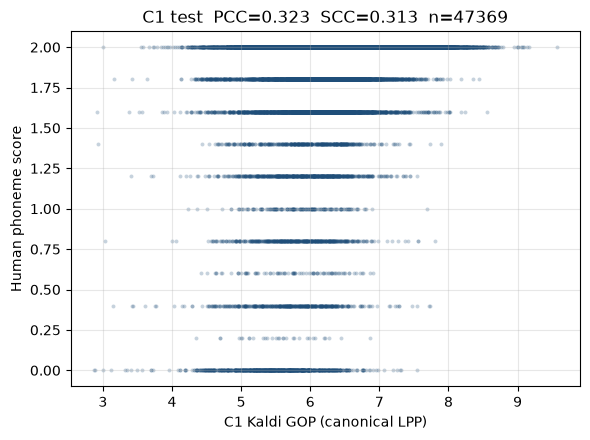

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(test["gop_c1"], test["human_score"], s=8, alpha=0.25, c="#1f4e79", linewidths=0)
ax.set_xlabel("C1 Kaldi GOP (canonical LPP)")
ax.set_ylabel("Human phoneme score")
c1 = cmp.get("C1", {})
ax.set_title(f"C1 test  PCC={c1.get('pcc', float('nan')):.3f}  SCC={c1.get('scc', float('nan')):.3f}  n={int(test['gop_c1'].notna().sum())}")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "c_scatter_c1_vs_human.png", dpi=140)
plt.show()


## Scatter: C2 Wav2Vec2 GOP vs human (test)

Skipped until `gop_c2` is populated by `extract_ssl_gop.py --model wav2vec2`.


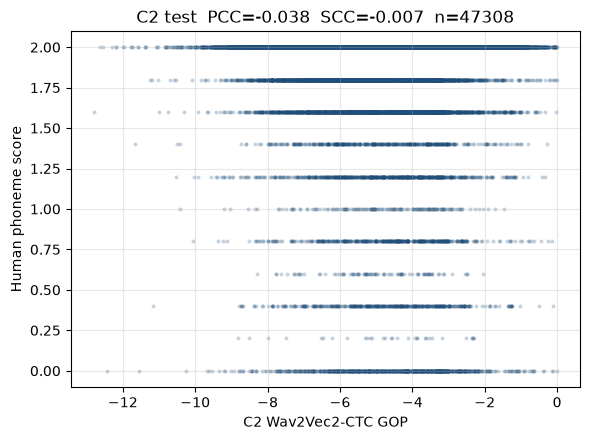

In [6]:
c2 = test[test["gop_c2"].notna()]
if c2.empty:
    print("C2 GOP not in predictions (run extract_ssl_gop.py --model wav2vec2)")
else:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(c2["gop_c2"], c2["human_score"], s=8, alpha=0.25, c="#1f4e79", linewidths=0)
    ax.set_xlabel("C2 Wav2Vec2-CTC GOP")
    ax.set_ylabel("Human phoneme score")
    m = cmp.get("C2") or {}
    ax.set_title(f"C2 test  PCC={m.get('pcc', float('nan')):.3f}  SCC={m.get('scc', float('nan')):.3f}  n={len(c2)}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT / "c_scatter_c2_vs_human.png", dpi=140)
    plt.show()


## Scatter: C3 HuBERT GOP vs human (test)

Skipped until a HuBERT phoneme-CTC checkpoint is fine-tuned and extracted. Embeddings are not GOP.


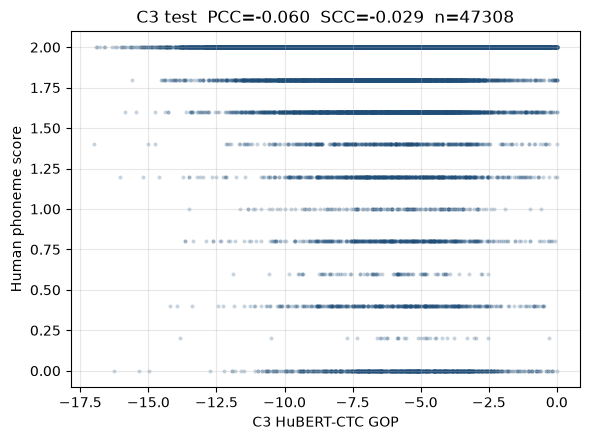

In [7]:
c3 = test[test["gop_c3"].notna()]
if c3.empty:
    print("C3 GOP not in predictions (fine-tune HuBERT phoneme CTC, then extract_ssl_gop.py --model hubert)")
else:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(c3["gop_c3"], c3["human_score"], s=8, alpha=0.25, c="#1f4e79", linewidths=0)
    ax.set_xlabel("C3 HuBERT-CTC GOP")
    ax.set_ylabel("Human phoneme score")
    m = cmp.get("C3") or {}
    ax.set_title(f"C3 test  PCC={m.get('pcc', float('nan')):.3f}  SCC={m.get('scc', float('nan')):.3f}  n={len(c3)}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT / "c_scatter_c3_vs_human.png", dpi=140)
    plt.show()
